## Exploración Extra: Temporal Feature Engineering - Stock Prices
## Práctica 11B - Dataset Alternativo
**Ingeniería de Datos — Universidad Católica del Uruguay**

## 🎯 Objetivo  
Aplicar el mismo pipeline de temporal feature engineering a un dataset alternativo de precios de acciones, incluyendo:  
- Lag features para capturar valores históricos
- Rolling y expanding windows para tendencias temporales
- Time window aggregations (7d, 30d, 90d)
- Encoding cíclico para variables temporales
- Validación temporal con TimeSeriesSplit

---

**Dataset alternativo:** Precios de acciones de múltiples empresas (S&P 500) para análisis temporal comparativo


In [16]:
import sys
!{sys.executable} -m pip install yfinance pandas numpy matplotlib seaborn scikit-learn --break-system-packages

In [17]:
!pip install -q yfinance pandas numpy matplotlib seaborn scikit-learn

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías listas")


zsh:1: command not found: pip
✅ Librerías listas


## 1) Carga de Datos - Precios de Acciones

Descargamos datos históricos de múltiples acciones para aplicar análisis temporal.


In [18]:
# Seleccionar múltiples acciones para análisis
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NVDA', 'JPM']

# Descargar datos históricos (últimos 2 años)
start_date = '2022-01-01'
end_date = '2024-01-01'

data_list = []
for ticker in tickers:
    try:
        stock = yf.download(ticker, start=start_date, end=end_date, progress=False)
        stock['ticker'] = ticker
        stock['date'] = stock.index
        stock = stock.reset_index()
        data_list.append(stock)
        print(f"✅ {ticker}: {len(stock)} días")
    except Exception as e:
        print(f"❌ Error con {ticker}: {e}")

# Procesar cada DataFrame individualmente antes de concatenar
processed_list = []
for stock_df in data_list:
    # Seleccionar y renombrar columnas para cada stock
    stock_clean = stock_df[['date', 'ticker', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()
    stock_clean.columns = ['date', 'stock', 'open', 'high', 'low', 'close', 'volume']
    processed_list.append(stock_clean)

# Combinar todos los datos procesados
df = pd.concat(processed_list, ignore_index=True)

# Ordenar por stock y fecha (CRÍTICO para features temporales)
df = df.sort_values(['stock', 'date']).reset_index(drop=True)

print(f"\n✅ Dataset completo: {len(df)} registros")
print(f"   Stocks: {df['stock'].nunique()}")
print(f"   Columnas: {df.columns.tolist()}")
print(f"   Período: {df['date'].min()} a {df['date'].max()}")
print(f"\nPrimeras filas:")
print(df.head())


✅ AAPL: 501 días
✅ MSFT: 501 días
✅ GOOGL: 501 días
✅ AMZN: 501 días
✅ TSLA: 501 días
✅ META: 501 días
✅ NVDA: 501 días
✅ JPM: 501 días

✅ Dataset completo: 4008 registros
   Stocks: 8
   Columnas: ['date', 'stock', 'open', 'high', 'low', 'close', 'volume']
   Período: 2022-01-03 00:00:00 a 2023-12-29 00:00:00

Primeras filas:
        date stock        open        high         low       close     volume
0 2022-01-03  AAPL  174.176216  179.122459  174.058687  178.270325  104487900
1 2022-01-04  AAPL  178.877588  179.181217  175.439697  176.007782   99310400
2 2022-01-05  AAPL  175.919612  176.468103  171.051728  171.325974   94537600
3 2022-01-06  AAPL  169.151587  171.698172  168.113369  168.465973   96904000
4 2022-01-07  AAPL  169.337715  170.562032  167.515931  168.632507   86709100


## 2) Exploración Temporal Inicial

Analizamos distribuciones temporales y patrones básicos.


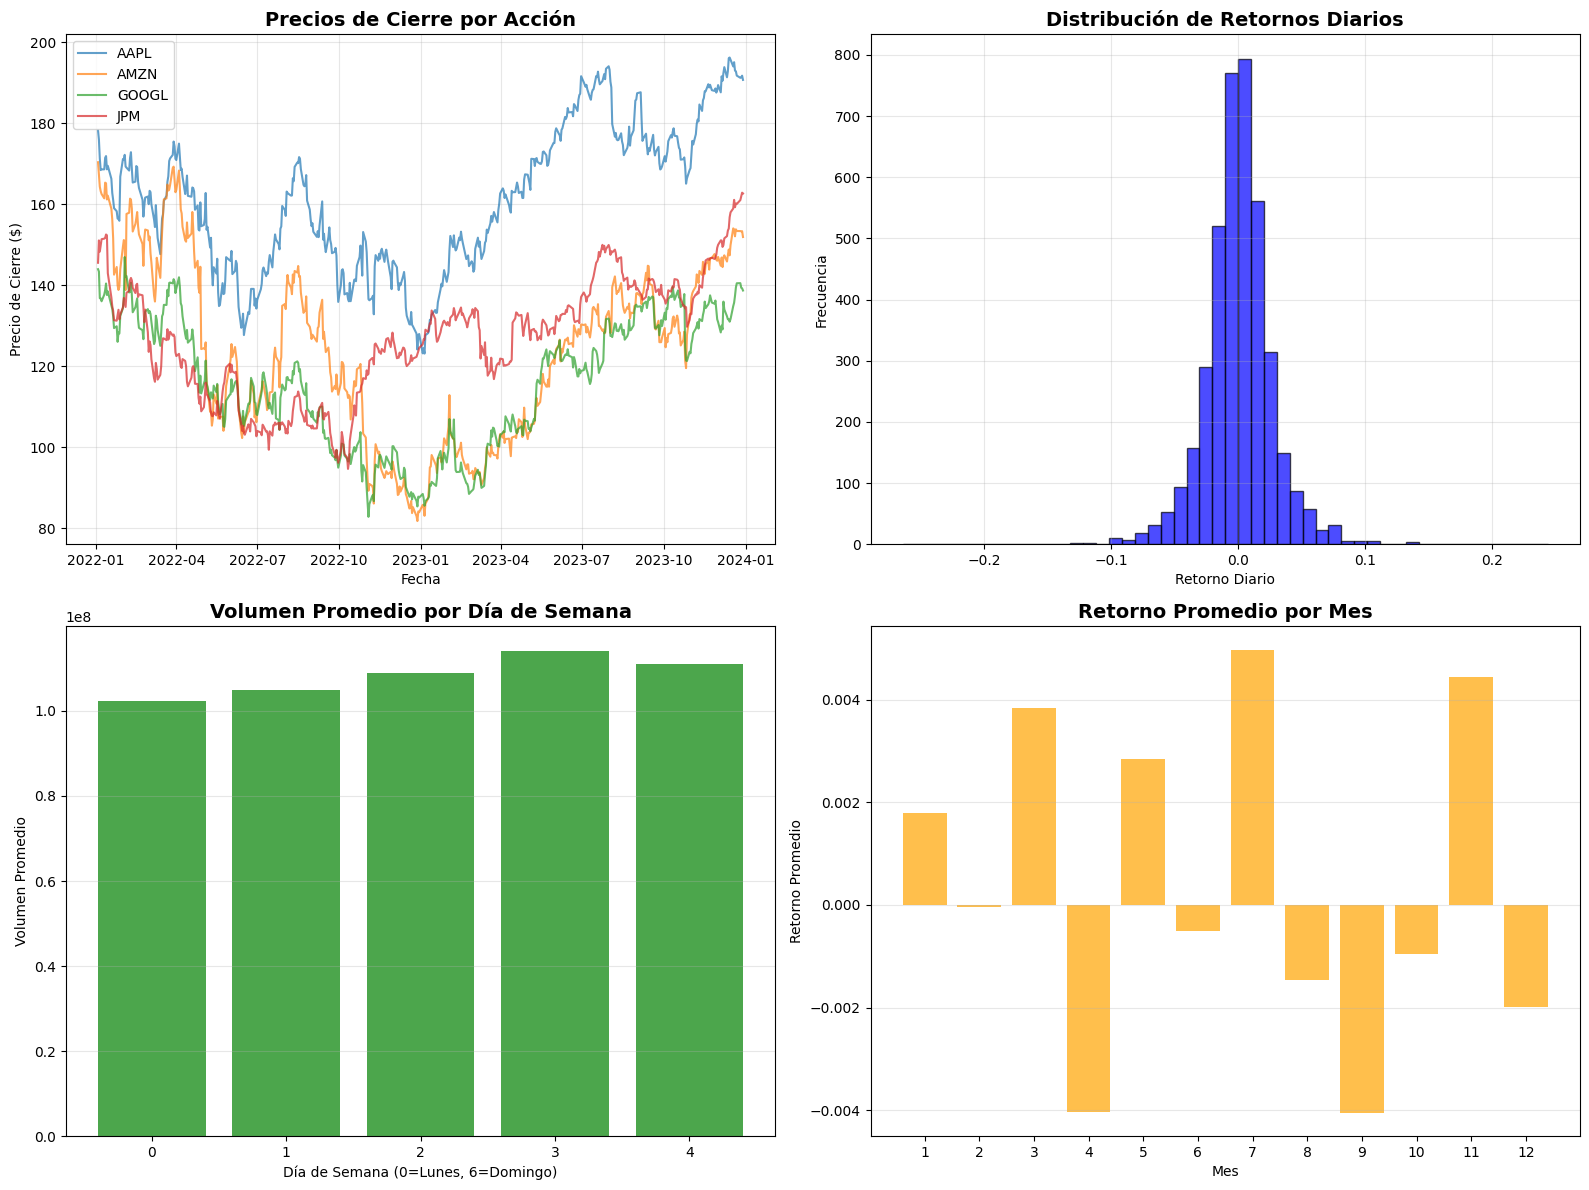


Estadísticas básicas:
Retorno promedio diario: 0.0004
Volatilidad (std retornos): 0.0274
Días con datos por stock: count      8.0
mean     501.0
std        0.0
min      501.0
25%      501.0
50%      501.0
75%      501.0
max      501.0
dtype: float64


In [19]:
# Calcular retornos diarios
df['daily_return'] = df.groupby('stock')['close'].pct_change()
df['price_change'] = df.groupby('stock')['close'].diff()

# Features temporales básicas
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['day_of_month'] = df['date'].dt.day

# Visualización de distribuciones temporales
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Precios de cierre por stock
for stock in df['stock'].unique()[:4]:  # Primeros 4 para no saturar
    stock_data = df[df['stock'] == stock]
    axes[0, 0].plot(stock_data['date'], stock_data['close'], label=stock, alpha=0.7)
axes[0, 0].set_title('Precios de Cierre por Acción', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Fecha')
axes[0, 0].set_ylabel('Precio de Cierre ($)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Distribución de retornos diarios
axes[0, 1].hist(df['daily_return'].dropna(), bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 1].set_title('Distribución de Retornos Diarios', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Retorno Diario')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].grid(True, alpha=0.3)

# Volumen por día de semana
df_weekday = df.groupby('day_of_week')['volume'].mean()
# Usar los índices reales del groupby (puede que no haya datos para todos los días)
axes[1, 0].bar(df_weekday.index, df_weekday.values, color='green', alpha=0.7)
axes[1, 0].set_title('Volumen Promedio por Día de Semana', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Día de Semana (0=Lunes, 6=Domingo)')
axes[1, 0].set_ylabel('Volumen Promedio')
axes[1, 0].set_xticks(df_weekday.index)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Retornos por mes
df_month = df.groupby('month')['daily_return'].mean()
# Usar los índices reales del groupby (puede que no haya datos para todos los meses)
axes[1, 1].bar(df_month.index, df_month.values, color='orange', alpha=0.7)
axes[1, 1].set_title('Retorno Promedio por Mes', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Mes')
axes[1, 1].set_ylabel('Retorno Promedio')
axes[1, 1].set_xticks(df_month.index)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../assets/temporal11b_exploration_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nEstadísticas básicas:")
print(f"Retorno promedio diario: {df['daily_return'].mean():.4f}")
print(f"Volatilidad (std retornos): {df['daily_return'].std():.4f}")
print(f"Días con datos por stock: {df.groupby('stock').size().describe()}")


## 3) Lag Features

Implementamos lag features para capturar valores históricos de precios y retornos.


In [20]:
# ⚠️ CRÍTICO: Usar .groupby() + .shift() previene data leakage
# Lag features de precio
df['close_lag_1'] = df.groupby('stock')['close'].shift(1)
df['close_lag_2'] = df.groupby('stock')['close'].shift(2)
df['close_lag_3'] = df.groupby('stock')['close'].shift(3)
df['close_lag_7'] = df.groupby('stock')['close'].shift(7)  # Semana anterior

# Lag features de retorno
df['return_lag_1'] = df.groupby('stock')['daily_return'].shift(1)
df['return_lag_2'] = df.groupby('stock')['daily_return'].shift(2)
df['return_lag_3'] = df.groupby('stock')['daily_return'].shift(3)

# Lag features de volumen
df['volume_lag_1'] = df.groupby('stock')['volume'].shift(1)
df['volume_lag_7'] = df.groupby('stock')['volume'].shift(7)

print("✅ Lag features creados")
print(f"\nEjemplo para {df['stock'].iloc[0]}:")
example = df[df['stock'] == df['stock'].iloc[0]][['date', 'close', 'close_lag_1', 'close_lag_2', 'daily_return', 'return_lag_1']].head(10)
print(example)


✅ Lag features creados

Ejemplo para AAPL:
        date       close  close_lag_1  close_lag_2  daily_return  return_lag_1
0 2022-01-03  178.270325          NaN          NaN           NaN           NaN
1 2022-01-04  176.007782   178.270325          NaN     -0.012692           NaN
2 2022-01-05  171.325974   176.007782   178.270325     -0.026600     -0.012692
3 2022-01-06  168.465973   171.325974   176.007782     -0.016693     -0.026600
4 2022-01-07  168.632507   168.465973   171.325974      0.000989     -0.016693
5 2022-01-10  168.652084   168.632507   168.465973      0.000116      0.000989
6 2022-01-11  171.482727   168.652084   168.632507      0.016784      0.000116
7 2022-01-12  171.923462   171.482727   168.652084      0.002570      0.016784
8 2022-01-13  168.652084   171.923462   171.482727     -0.019028      0.002570
9 2022-01-14  169.514008   168.652084   171.923462      0.005111     -0.019028


## 4) Rolling Window Features

Calculamos estadísticas sobre ventanas móviles de los últimos N días.


✅ Rolling window features creados


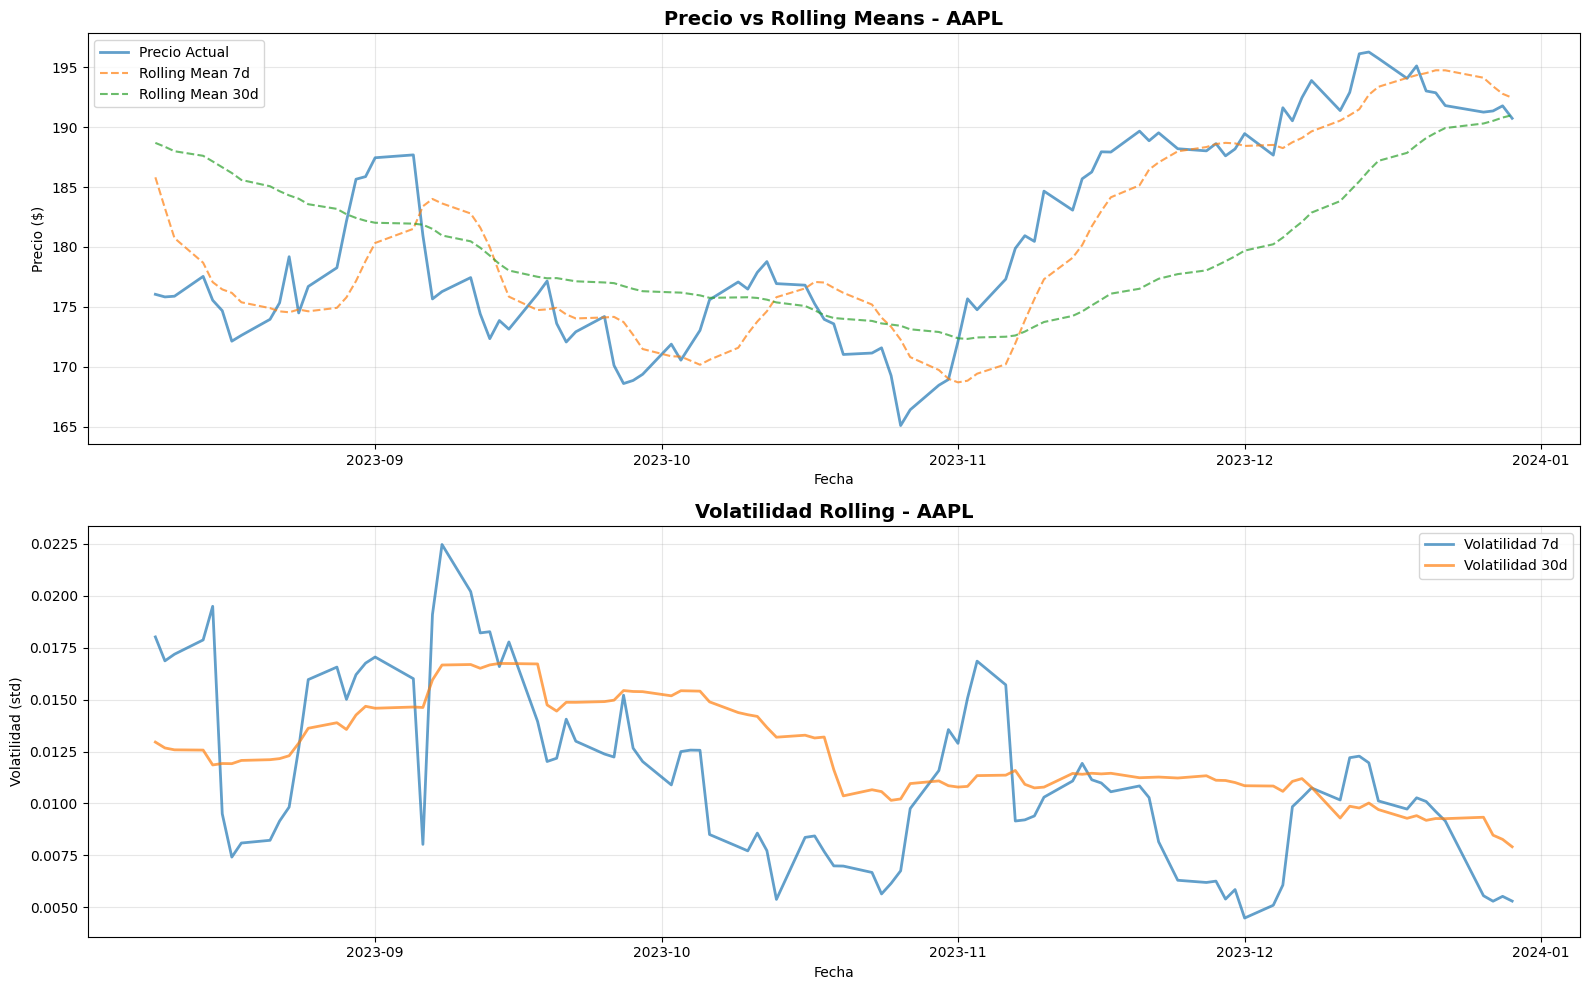

In [21]:
# ⚠️ CRÍTICO: Usar .shift(1) ANTES de .rolling() para excluir el día actual
# Rolling mean de precio (últimos 7, 14, 30 días)
df['rolling_close_mean_7'] = (
    df.groupby('stock')['close']
    .shift(1)  # Excluir día actual
    .rolling(window=7, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

df['rolling_close_mean_30'] = (
    df.groupby('stock')['close']
    .shift(1)
    .rolling(window=30, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

# Rolling std de retornos (volatilidad)
df['rolling_return_std_7'] = (
    df.groupby('stock')['daily_return']
    .shift(1)
    .rolling(window=7, min_periods=1)
    .std()
    .reset_index(level=0, drop=True)
)

df['rolling_return_std_30'] = (
    df.groupby('stock')['daily_return']
    .shift(1)
    .rolling(window=30, min_periods=1)
    .std()
    .reset_index(level=0, drop=True)
)

# Rolling max/min de precio
df['rolling_close_max_30'] = (
    df.groupby('stock')['close']
    .shift(1)
    .rolling(window=30, min_periods=1)
    .max()
    .reset_index(level=0, drop=True)
)

df['rolling_close_min_30'] = (
    df.groupby('stock')['close']
    .shift(1)
    .rolling(window=30, min_periods=1)
    .min()
    .reset_index(level=0, drop=True)
)

print("✅ Rolling window features creados")

# Visualización
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Precio actual vs rolling mean
stock_example = df['stock'].iloc[0]
stock_data = df[df['stock'] == stock_example].tail(100)

axes[0].plot(stock_data['date'], stock_data['close'], label='Precio Actual', alpha=0.7, linewidth=2)
axes[0].plot(stock_data['date'], stock_data['rolling_close_mean_7'], label='Rolling Mean 7d', alpha=0.7, linestyle='--')
axes[0].plot(stock_data['date'], stock_data['rolling_close_mean_30'], label='Rolling Mean 30d', alpha=0.7, linestyle='--')
axes[0].set_title(f'Precio vs Rolling Means - {stock_example}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Precio ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Volatilidad rolling
axes[1].plot(stock_data['date'], stock_data['rolling_return_std_7'], label='Volatilidad 7d', alpha=0.7, linewidth=2)
axes[1].plot(stock_data['date'], stock_data['rolling_return_std_30'], label='Volatilidad 30d', alpha=0.7, linewidth=2)
axes[1].set_title(f'Volatilidad Rolling - {stock_example}', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Volatilidad (std)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../assets/temporal11b_rolling_features.png', dpi=150, bbox_inches='tight')
plt.show()


## 5) Expanding Window Features

Calculamos estadísticas desde el inicio hasta ahora (comportamiento histórico acumulado).


✅ Expanding window features creados


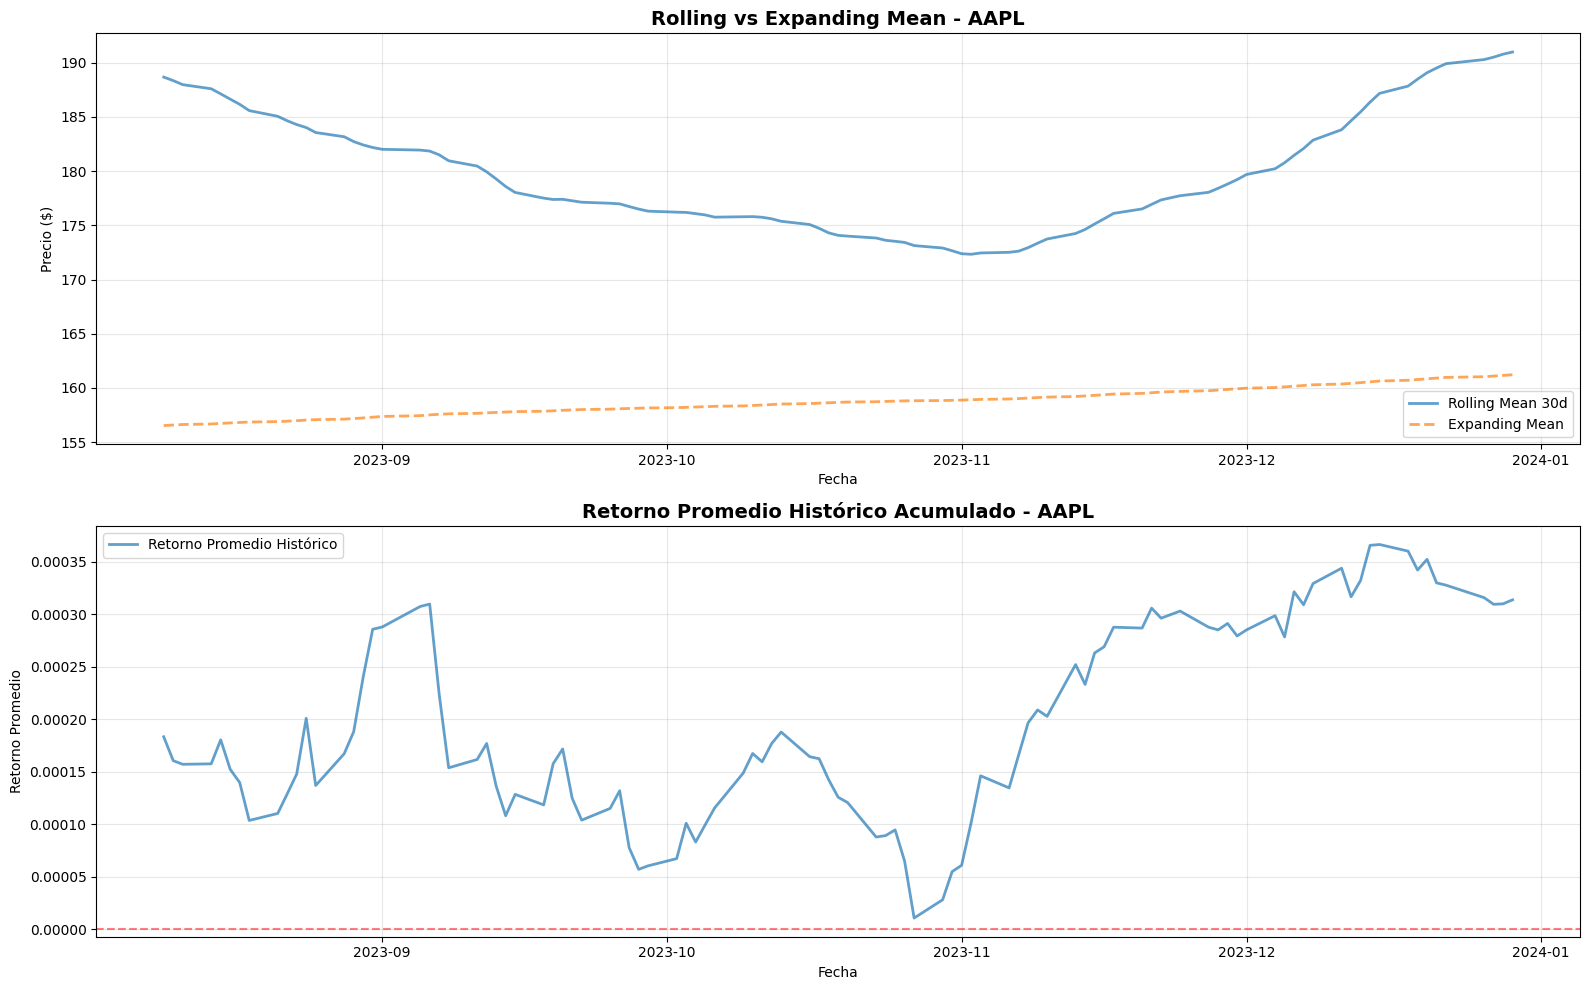

In [22]:
# Expanding window features
df['expanding_close_mean'] = (
    df.groupby('stock')['close']
    .shift(1)
    .expanding(min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

df['expanding_return_mean'] = (
    df.groupby('stock')['daily_return']
    .shift(1)
    .expanding(min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

df['expanding_return_std'] = (
    df.groupby('stock')['daily_return']
    .shift(1)
    .expanding(min_periods=1)
    .std()
    .reset_index(level=0, drop=True)
)

df['expanding_volume_mean'] = (
    df.groupby('stock')['volume']
    .shift(1)
    .expanding(min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

# Total de días desde inicio
df['days_since_start'] = df.groupby('stock').cumcount()

print("✅ Expanding window features creados")

# Visualización comparativa
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

stock_example = df['stock'].iloc[0]
stock_data = df[df['stock'] == stock_example].tail(100)

# Rolling vs Expanding mean
axes[0].plot(stock_data['date'], stock_data['rolling_close_mean_30'], 
             label='Rolling Mean 30d', alpha=0.7, linewidth=2)
axes[0].plot(stock_data['date'], stock_data['expanding_close_mean'], 
             label='Expanding Mean', alpha=0.7, linewidth=2, linestyle='--')
axes[0].set_title(f'Rolling vs Expanding Mean - {stock_example}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Precio ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Retorno histórico
axes[1].plot(stock_data['date'], stock_data['expanding_return_mean'], 
             label='Retorno Promedio Histórico', alpha=0.7, linewidth=2)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title(f'Retorno Promedio Histórico Acumulado - {stock_example}', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Retorno Promedio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../assets/temporal11b_rolling_vs_expanding.png', dpi=150, bbox_inches='tight')
plt.show()


## 6) Time Window Aggregations

Agregaciones por ventanas temporales específicas (7d, 30d, 90d).


✅ Time window aggregations creados


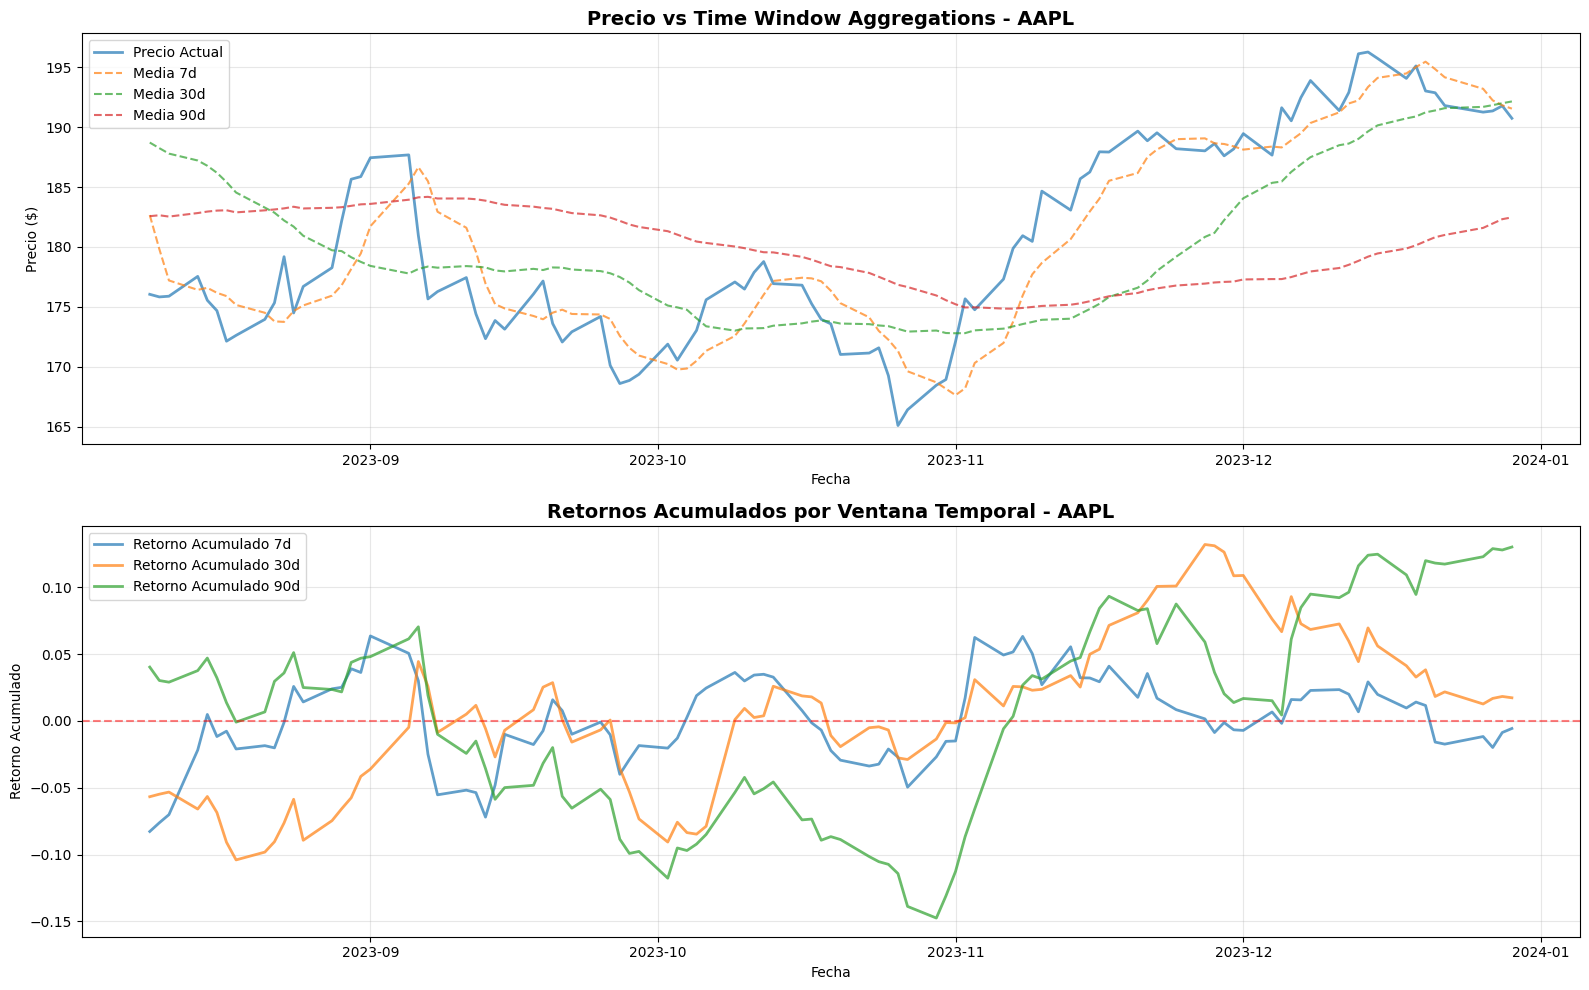

In [23]:
# Asegurar que 'date' esté como columna (no como índice)
if 'date' in df.index.names:
    df = df.reset_index()
elif df.index.name == 'date':
    df = df.reset_index()

# Convertir fecha a datetime si no lo es
df['date'] = pd.to_datetime(df['date'])

# Time window aggregations por stock
def create_time_window_features(group):
    # Ordenar por fecha
    group = group.sort_values('date').copy()
    group = group.set_index('date')
    
    # Agregaciones de 7 días
    rolling_7d = group.shift(1).rolling('7D', min_periods=1)
    group['price_mean_7d'] = rolling_7d['close'].mean()
    group['return_sum_7d'] = rolling_7d['daily_return'].sum()
    group['volume_sum_7d'] = rolling_7d['volume'].sum()
    
    # Agregaciones de 30 días
    rolling_30d = group.shift(1).rolling('30D', min_periods=1)
    group['price_mean_30d'] = rolling_30d['close'].mean()
    group['return_sum_30d'] = rolling_30d['daily_return'].sum()
    group['volume_sum_30d'] = rolling_30d['volume'].sum()
    
    # Agregaciones de 90 días
    rolling_90d = group.shift(1).rolling('90D', min_periods=1)
    group['price_mean_90d'] = rolling_90d['close'].mean()
    group['return_sum_90d'] = rolling_90d['daily_return'].sum()
    
    # Resetear índice para mantener 'date' como columna
    group = group.reset_index()
    return group

df = df.groupby('stock').apply(create_time_window_features)
# Resetear solo el nivel del groupby (stock) sin crear columna
df = df.reset_index(level=0, drop=True).reset_index(drop=True)

print("✅ Time window aggregations creados")

# Visualización
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

stock_example = df['stock'].iloc[0]
stock_data = df[df['stock'] == stock_example].tail(100)

# Precio vs medias de ventanas temporales
axes[0].plot(stock_data['date'], stock_data['close'], label='Precio Actual', alpha=0.7, linewidth=2)
axes[0].plot(stock_data['date'], stock_data['price_mean_7d'], label='Media 7d', alpha=0.7, linestyle='--')
axes[0].plot(stock_data['date'], stock_data['price_mean_30d'], label='Media 30d', alpha=0.7, linestyle='--')
axes[0].plot(stock_data['date'], stock_data['price_mean_90d'], label='Media 90d', alpha=0.7, linestyle='--')
axes[0].set_title(f'Precio vs Time Window Aggregations - {stock_example}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Precio ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Retornos acumulados por ventana
axes[1].plot(stock_data['date'], stock_data['return_sum_7d'], label='Retorno Acumulado 7d', alpha=0.7, linewidth=2)
axes[1].plot(stock_data['date'], stock_data['return_sum_30d'], label='Retorno Acumulado 30d', alpha=0.7, linewidth=2)
axes[1].plot(stock_data['date'], stock_data['return_sum_90d'], label='Retorno Acumulado 90d', alpha=0.7, linewidth=2)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title(f'Retornos Acumulados por Ventana Temporal - {stock_example}', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Retorno Acumulado')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../assets/temporal11b_time_windows.png', dpi=150, bbox_inches='tight')
plt.show()


## 7) Encoding Cíclico

Aplicamos encoding cíclico para variables temporales (día de semana, mes).


✅ Encoding cíclico creado


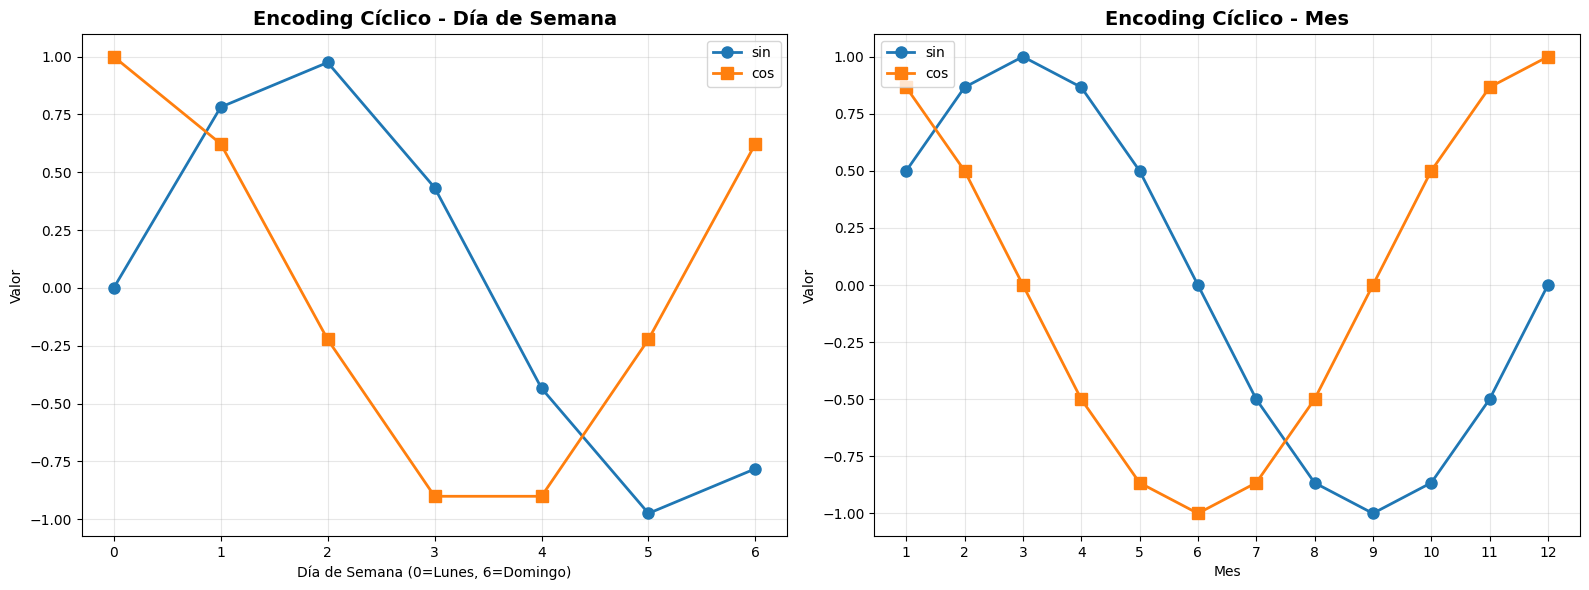

In [24]:
# Encoding cíclico para día de semana (0-6)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Encoding cíclico para mes (1-12)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Encoding cíclico para día del mes (1-31)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_month'] / 31)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_month'] / 31)

print("✅ Encoding cíclico creado")

# Visualización del encoding cíclico
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Día de semana cíclico
dow_range = np.arange(7)
dow_sin = np.sin(2 * np.pi * dow_range / 7)
dow_cos = np.cos(2 * np.pi * dow_range / 7)

axes[0].plot(dow_range, dow_sin, marker='o', label='sin', linewidth=2, markersize=8)
axes[0].plot(dow_range, dow_cos, marker='s', label='cos', linewidth=2, markersize=8)
axes[0].set_title('Encoding Cíclico - Día de Semana', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Día de Semana (0=Lunes, 6=Domingo)')
axes[0].set_ylabel('Valor')
axes[0].set_xticks(dow_range)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Mes cíclico
month_range = np.arange(1, 13)
month_sin = np.sin(2 * np.pi * month_range / 12)
month_cos = np.cos(2 * np.pi * month_range / 12)

axes[1].plot(month_range, month_sin, marker='o', label='sin', linewidth=2, markersize=8)
axes[1].plot(month_range, month_cos, marker='s', label='cos', linewidth=2, markersize=8)
axes[1].set_title('Encoding Cíclico - Mes', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Valor')
axes[1].set_xticks(month_range)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../assets/temporal11b_cyclic_encoding.png', dpi=150, bbox_inches='tight')
plt.show()


## 8) Target Variable y Modelo

Creamos un target binario (subida/bajada de precio) y evaluamos el impacto de las features temporales.


In [25]:
# Crear target: 1 si el precio sube al día siguiente, 0 si baja
df['target'] = (df.groupby('stock')['close'].shift(-1) > df['close']).astype(int)

# Seleccionar features para el modelo
feature_cols = [
    # Lag features
    'close_lag_1', 'close_lag_7', 'return_lag_1', 'volume_lag_1',
    # Rolling features
    'rolling_close_mean_7', 'rolling_close_mean_30',
    'rolling_return_std_7', 'rolling_return_std_30',
    # Expanding features
    'expanding_close_mean', 'expanding_return_mean', 'expanding_return_std',
    # Time windows
    'price_mean_7d', 'price_mean_30d', 'return_sum_7d', 'return_sum_30d',
    # Cyclic encoding
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    # Básicas
    'open', 'high', 'low', 'volume'
]

# Limpiar datos para modelo
df_model = df[['stock', 'date', 'target'] + feature_cols].copy()
df_model = df_model.dropna()

print(f"✅ Dataset para modelo: {len(df_model)} registros")
print(f"   Distribución target: {df_model['target'].value_counts().to_dict()}")

# Separar por stock para análisis
print(f"\nRegistros por stock:")
print(df_model.groupby('stock').size())


✅ Dataset para modelo: 3952 registros
   Distribución target: {1: 2018, 0: 1934}

Registros por stock:
stock
AAPL     494
AMZN     494
GOOGL    494
JPM      494
META     494
MSFT     494
NVDA     494
TSLA     494
dtype: int64


Train: 1976 registros
Test: 1976 registros

📊 Resultados del Modelo:
              precision    recall  f1-score   support

           0       0.49      0.60      0.54       956
           1       0.53      0.43      0.47      1020

    accuracy                           0.51      1976
   macro avg       0.51      0.51      0.51      1976
weighted avg       0.51      0.51      0.51      1976


ROC-AUC: 0.5107

🔝 Top 10 Features más importantes:
                  feature  importance
2            return_lag_1    0.068253
14         return_sum_30d    0.067160
13          return_sum_7d    0.060123
3            volume_lag_1    0.058077
22                 volume    0.055891
6    rolling_return_std_7    0.052955
7   rolling_return_std_30    0.052459
10   expanding_return_std    0.049071
8    expanding_close_mean    0.047193
11          price_mean_7d    0.045423


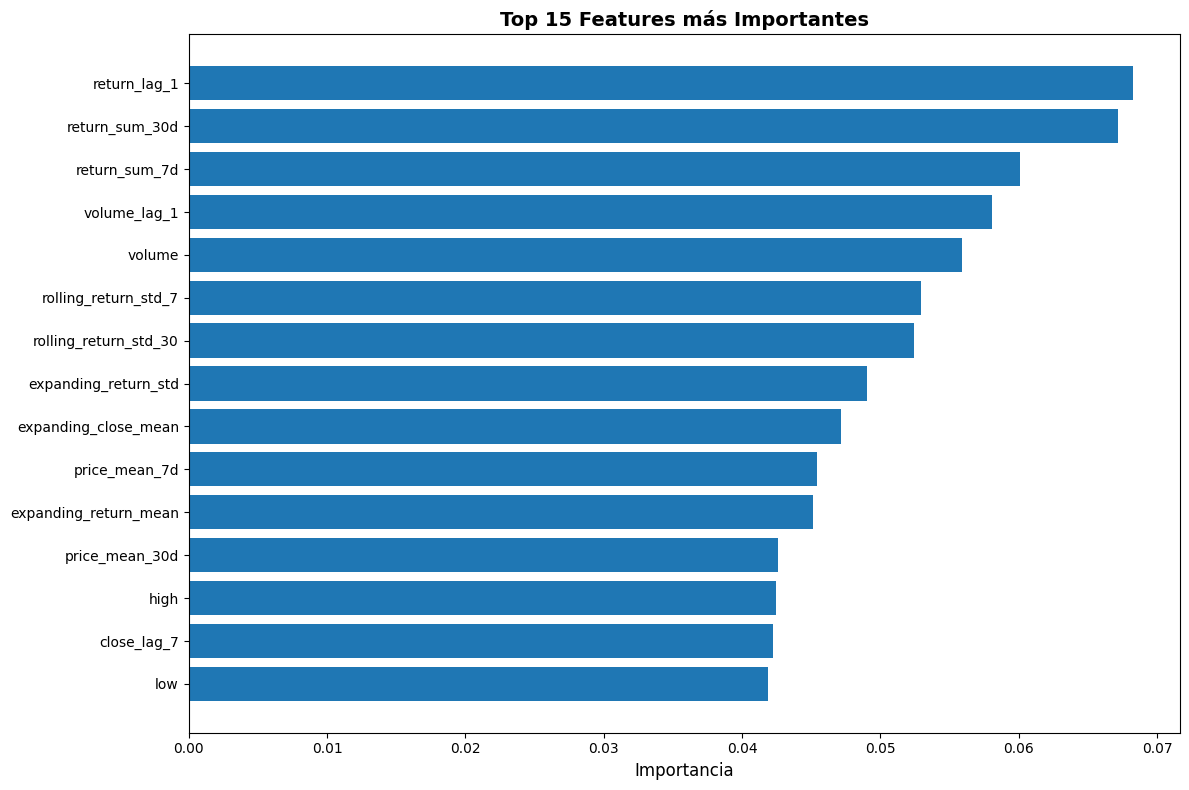

In [26]:
# Entrenar modelo con validación temporal
# Usar un stock para entrenamiento y otro para test
train_stocks = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
test_stocks = ['TSLA', 'META', 'NVDA', 'JPM']

train_data = df_model[df_model['stock'].isin(train_stocks)].copy()
test_data = df_model[df_model['stock'].isin(test_stocks)].copy()

# Ordenar por fecha (CRÍTICO para validación temporal)
train_data = train_data.sort_values('date')
test_data = test_data.sort_values('date')

X_train = train_data[feature_cols].fillna(0)
y_train = train_data['target']
X_test = test_data[feature_cols].fillna(0)
y_test = test_data['target']

print(f"Train: {len(X_train)} registros")
print(f"Test: {len(X_test)} registros")

# Modelo Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)

# Predicciones
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

# Métricas
print("\n📊 Resultados del Modelo:")
print(classification_report(y_test, y_pred))
print(f"\nROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Importancia de features
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n🔝 Top 10 Features más importantes:")
print(feature_importance.head(10))

# Visualización de importancia
fig, ax = plt.subplots(figsize=(12, 8))
top_features = feature_importance.head(15)
ax.barh(range(len(top_features)), top_features['importance'].values)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.set_xlabel('Importancia', fontsize=12)
ax.set_title('Top 15 Features más Importantes', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../assets/temporal11b_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 📝 Reflexiones y Aprendizajes

### Comparación con la Práctica Original:

1. **Universalidad del pipeline**: Las mismas técnicas temporales funcionan en diferentes dominios (e-commerce vs finanzas).

2. **Lag features efectivos**: Los precios y retornos históricos son predictores fuertes en mercados financieros.

3. **Rolling windows**: Capturan tendencias recientes que son críticas en análisis de acciones.

4. **Encoding cíclico**: Útil para capturar patrones estacionales (día de semana, mes).

5. **Validación temporal**: Fundamental para evitar data leakage en datos financieros.

### Aplicabilidad Metodológica:

El pipeline de temporal feature engineering es **universal** y aplicable a cualquier dominio con datos temporales, demostrando la versatilidad de las técnicas implementadas.
